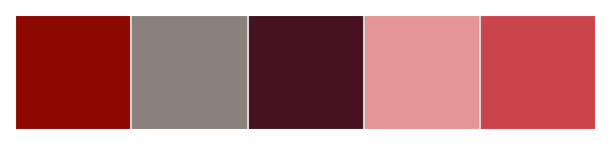

In [1]:
# Data manipulation and visualization.
import pandas as pd
import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt 
import seaborn as sns

# Utils.
from src.eda_utils import *

# Display options.
pd.set_option('display.max_rows', None)
pd.set_option('display.max_info_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Filter warnings.
import warnings
warnings.filterwarnings('ignore')

# Visualization Settings
mpl.style.use('ggplot')
mpl.rcParams['axes.facecolor']      = 'white'
mpl.rcParams['grid.color']          = 'lightgray'
mpl.rcParams['xtick.color']         = 'black'
mpl.rcParams['ytick.color']         = 'black'
mpl.rcParams['axes.grid']           = True
mpl.rcParams['figure.dpi']          = 150

# Palette Seting
instyle_palette = ['#8d0801', '#8a817c', '#461220', '#e39695', '#cc444b']
sns.set_palette(sns.color_palette(instyle_palette))
sns.palplot(sns.color_palette(instyle_palette))

In [2]:
import pandas as pd

caminho_arquivo = '../artifacts/dados_case_ecoshop.csv'


df = pd.read_csv(caminho_arquivo)
display(df.head())

print("\nResumo da Base de Dados:")
df.info()

,ad_id,date,campaign_name,impressions,reach,frequency,clicks,ctr,conversions,spend,cpc,cpa,roas
0,50070,2025-01-01,EcoShop_RTG_Cart_30d,101435,62614,1.62,1291,1.27,215,3125.16,2.42,14.54,12.38
1,50029,2025-01-02,EcoShop_Acq_LAL_1%,45437,19252,2.36,401,0.88,18,918.96,2.29,51.05,3.53
2,50078,2025-01-05,EcoShop_Acq_LAL_1%,240138,96829,2.48,2739,1.14,184,3999.21,1.46,21.73,8.28
3,50096,2025-01-07,EcoShop_RTG_Cart_30d,180876,98302,1.84,2979,1.65,371,4528.43,1.52,12.21,14.75
4,50137,2025-01-07,EcoShop_Acq_Interesses,65485,57442,1.14,961,1.47,56,884.79,0.92,15.80,11.39



Resumo da Base de Dados:
<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 13 columns):
 #   Column         Dtype  
---  ------         -----  
 0   ad_id          int64  
 1   date           str    
 2   campaign_name  str    
 3   impressions    int64  
 4   reach          int64  
 5   frequency      float64
 6   clicks         int64  
 7   ctr            float64
 8   conversions    int64  
 9   spend          float64
 10  cpc            float64
 11  cpa            float64
 12  roas           float64
dtypes: float64(6), int64(5), str(2)
memory usage: 35.7 KB


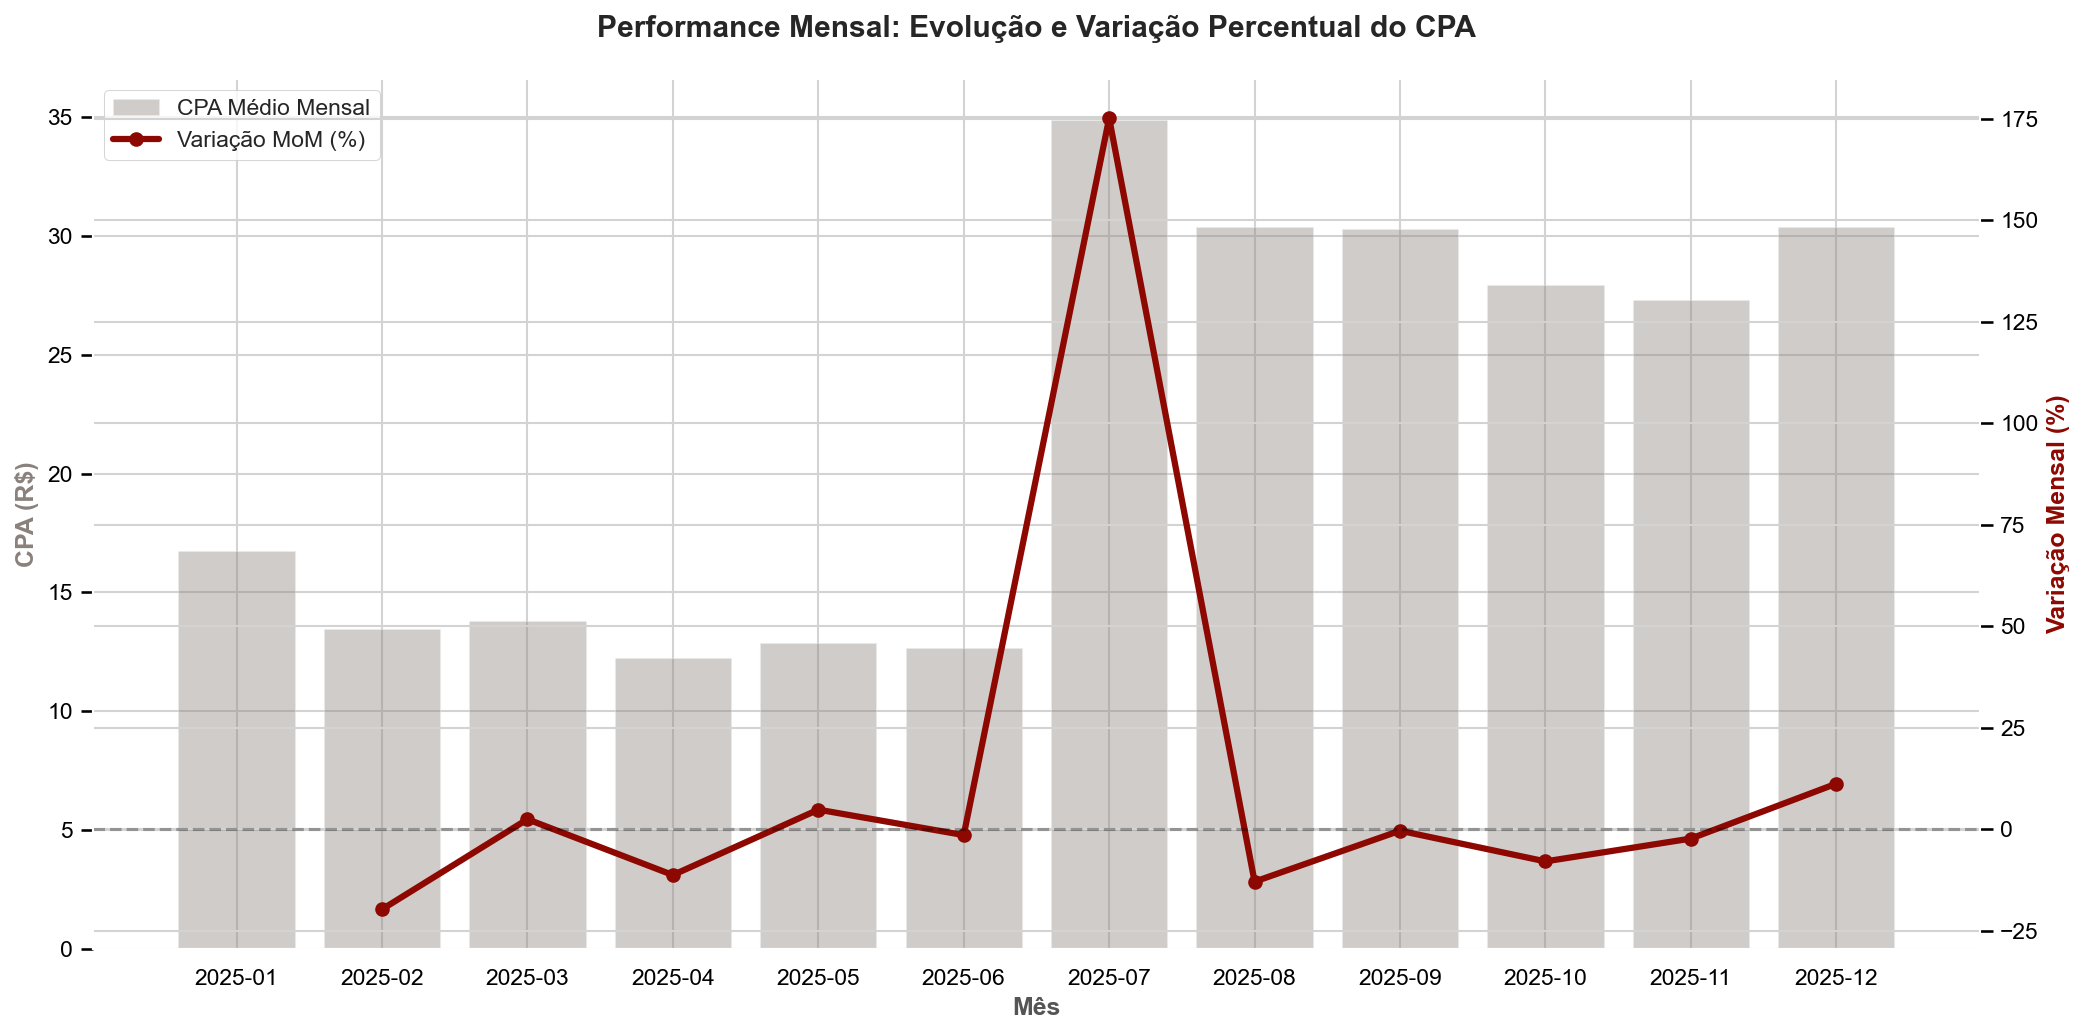

In [3]:
# Chamada minimalista para análise de série temporal
monthly_data = analise_mensal_cpa('../artifacts/dados_case_ecoshop.csv')

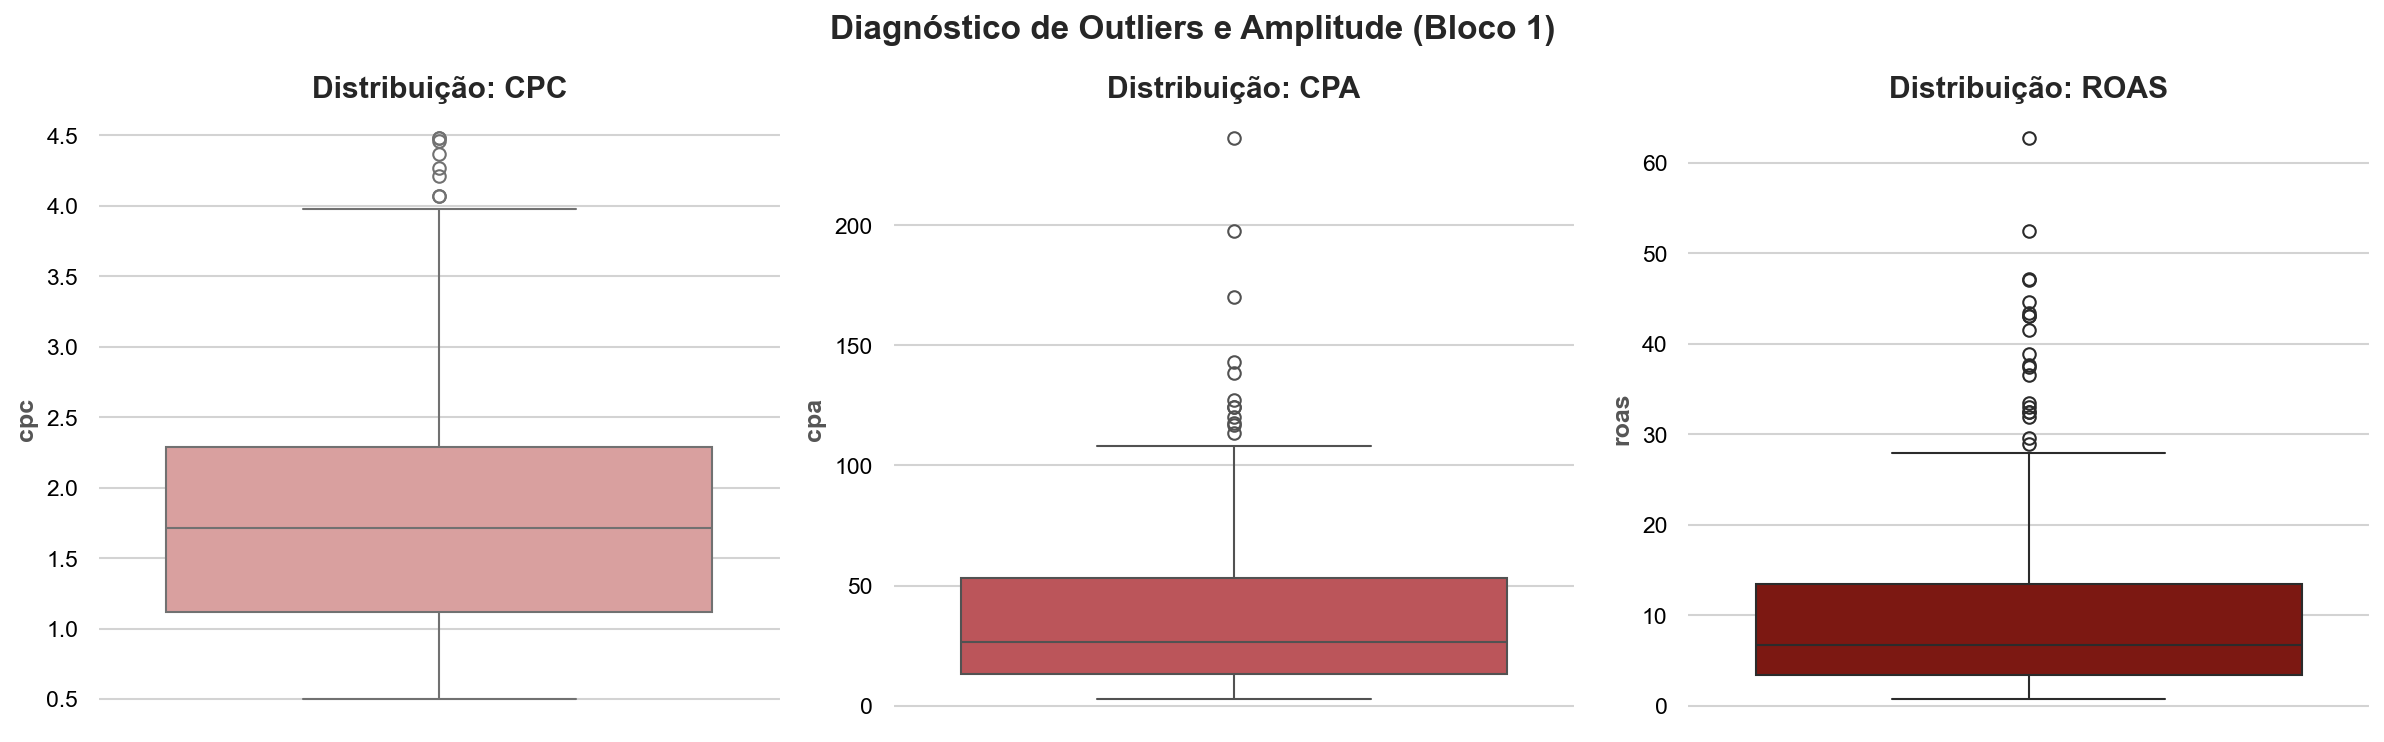

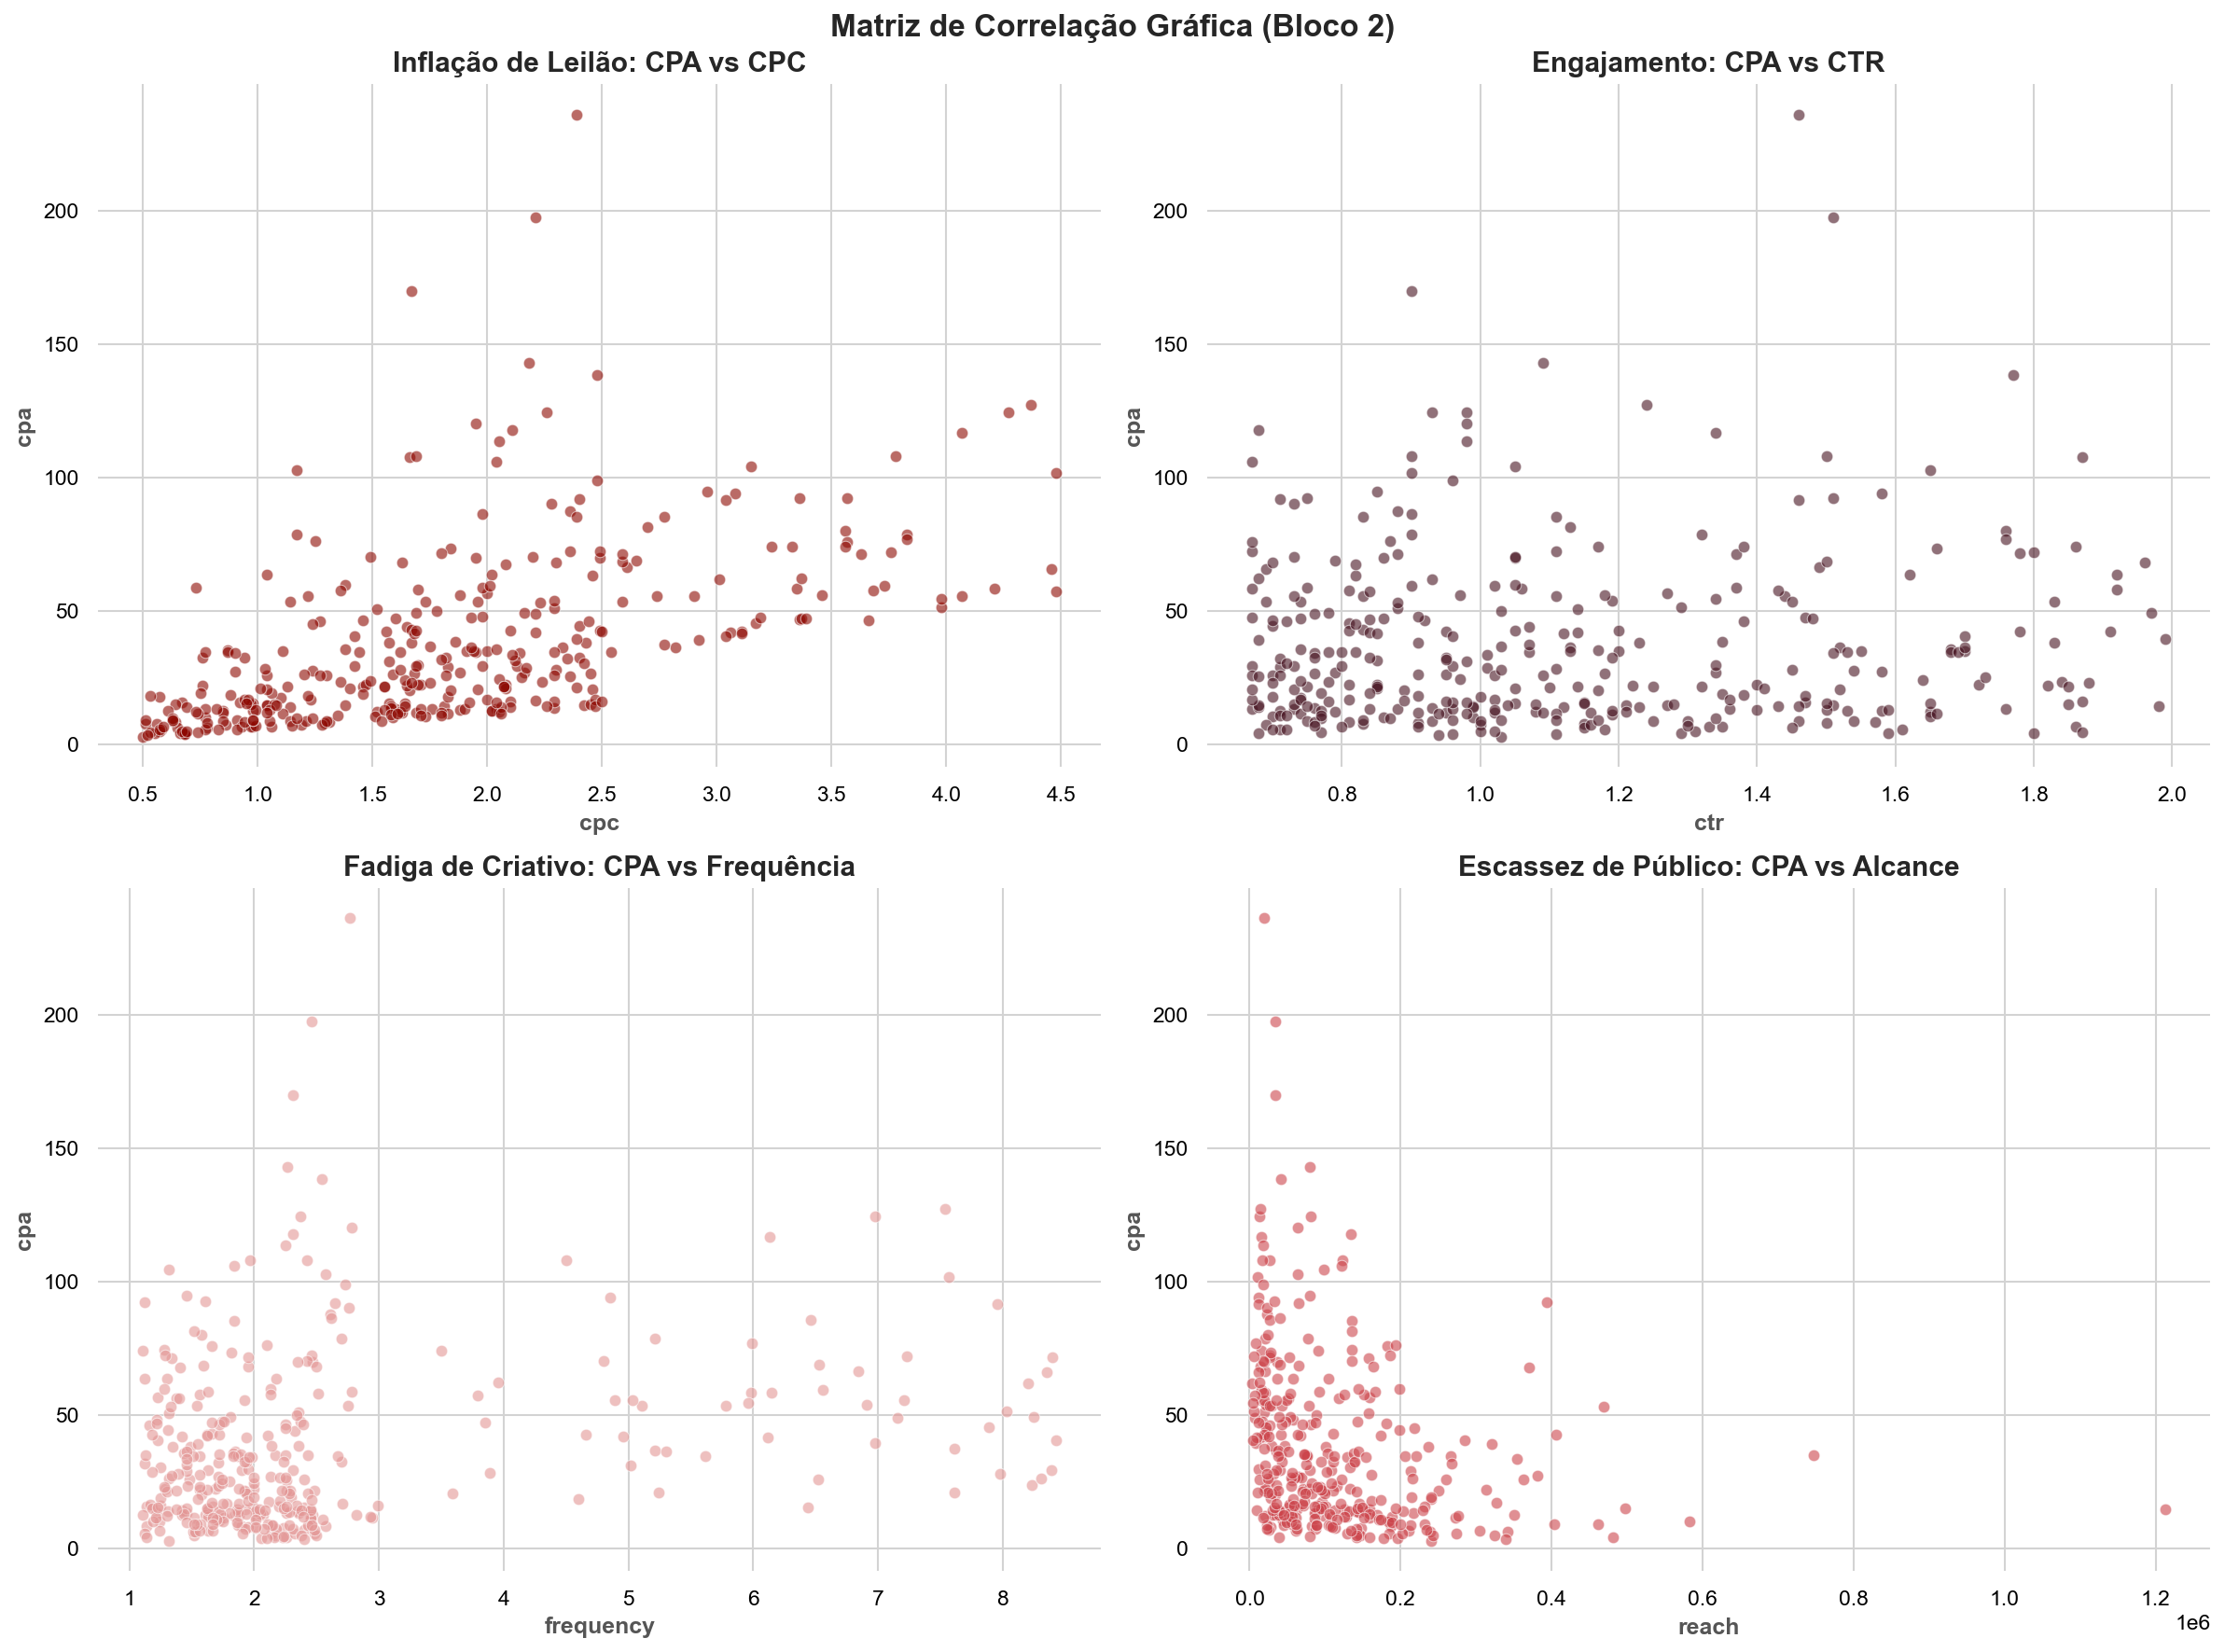

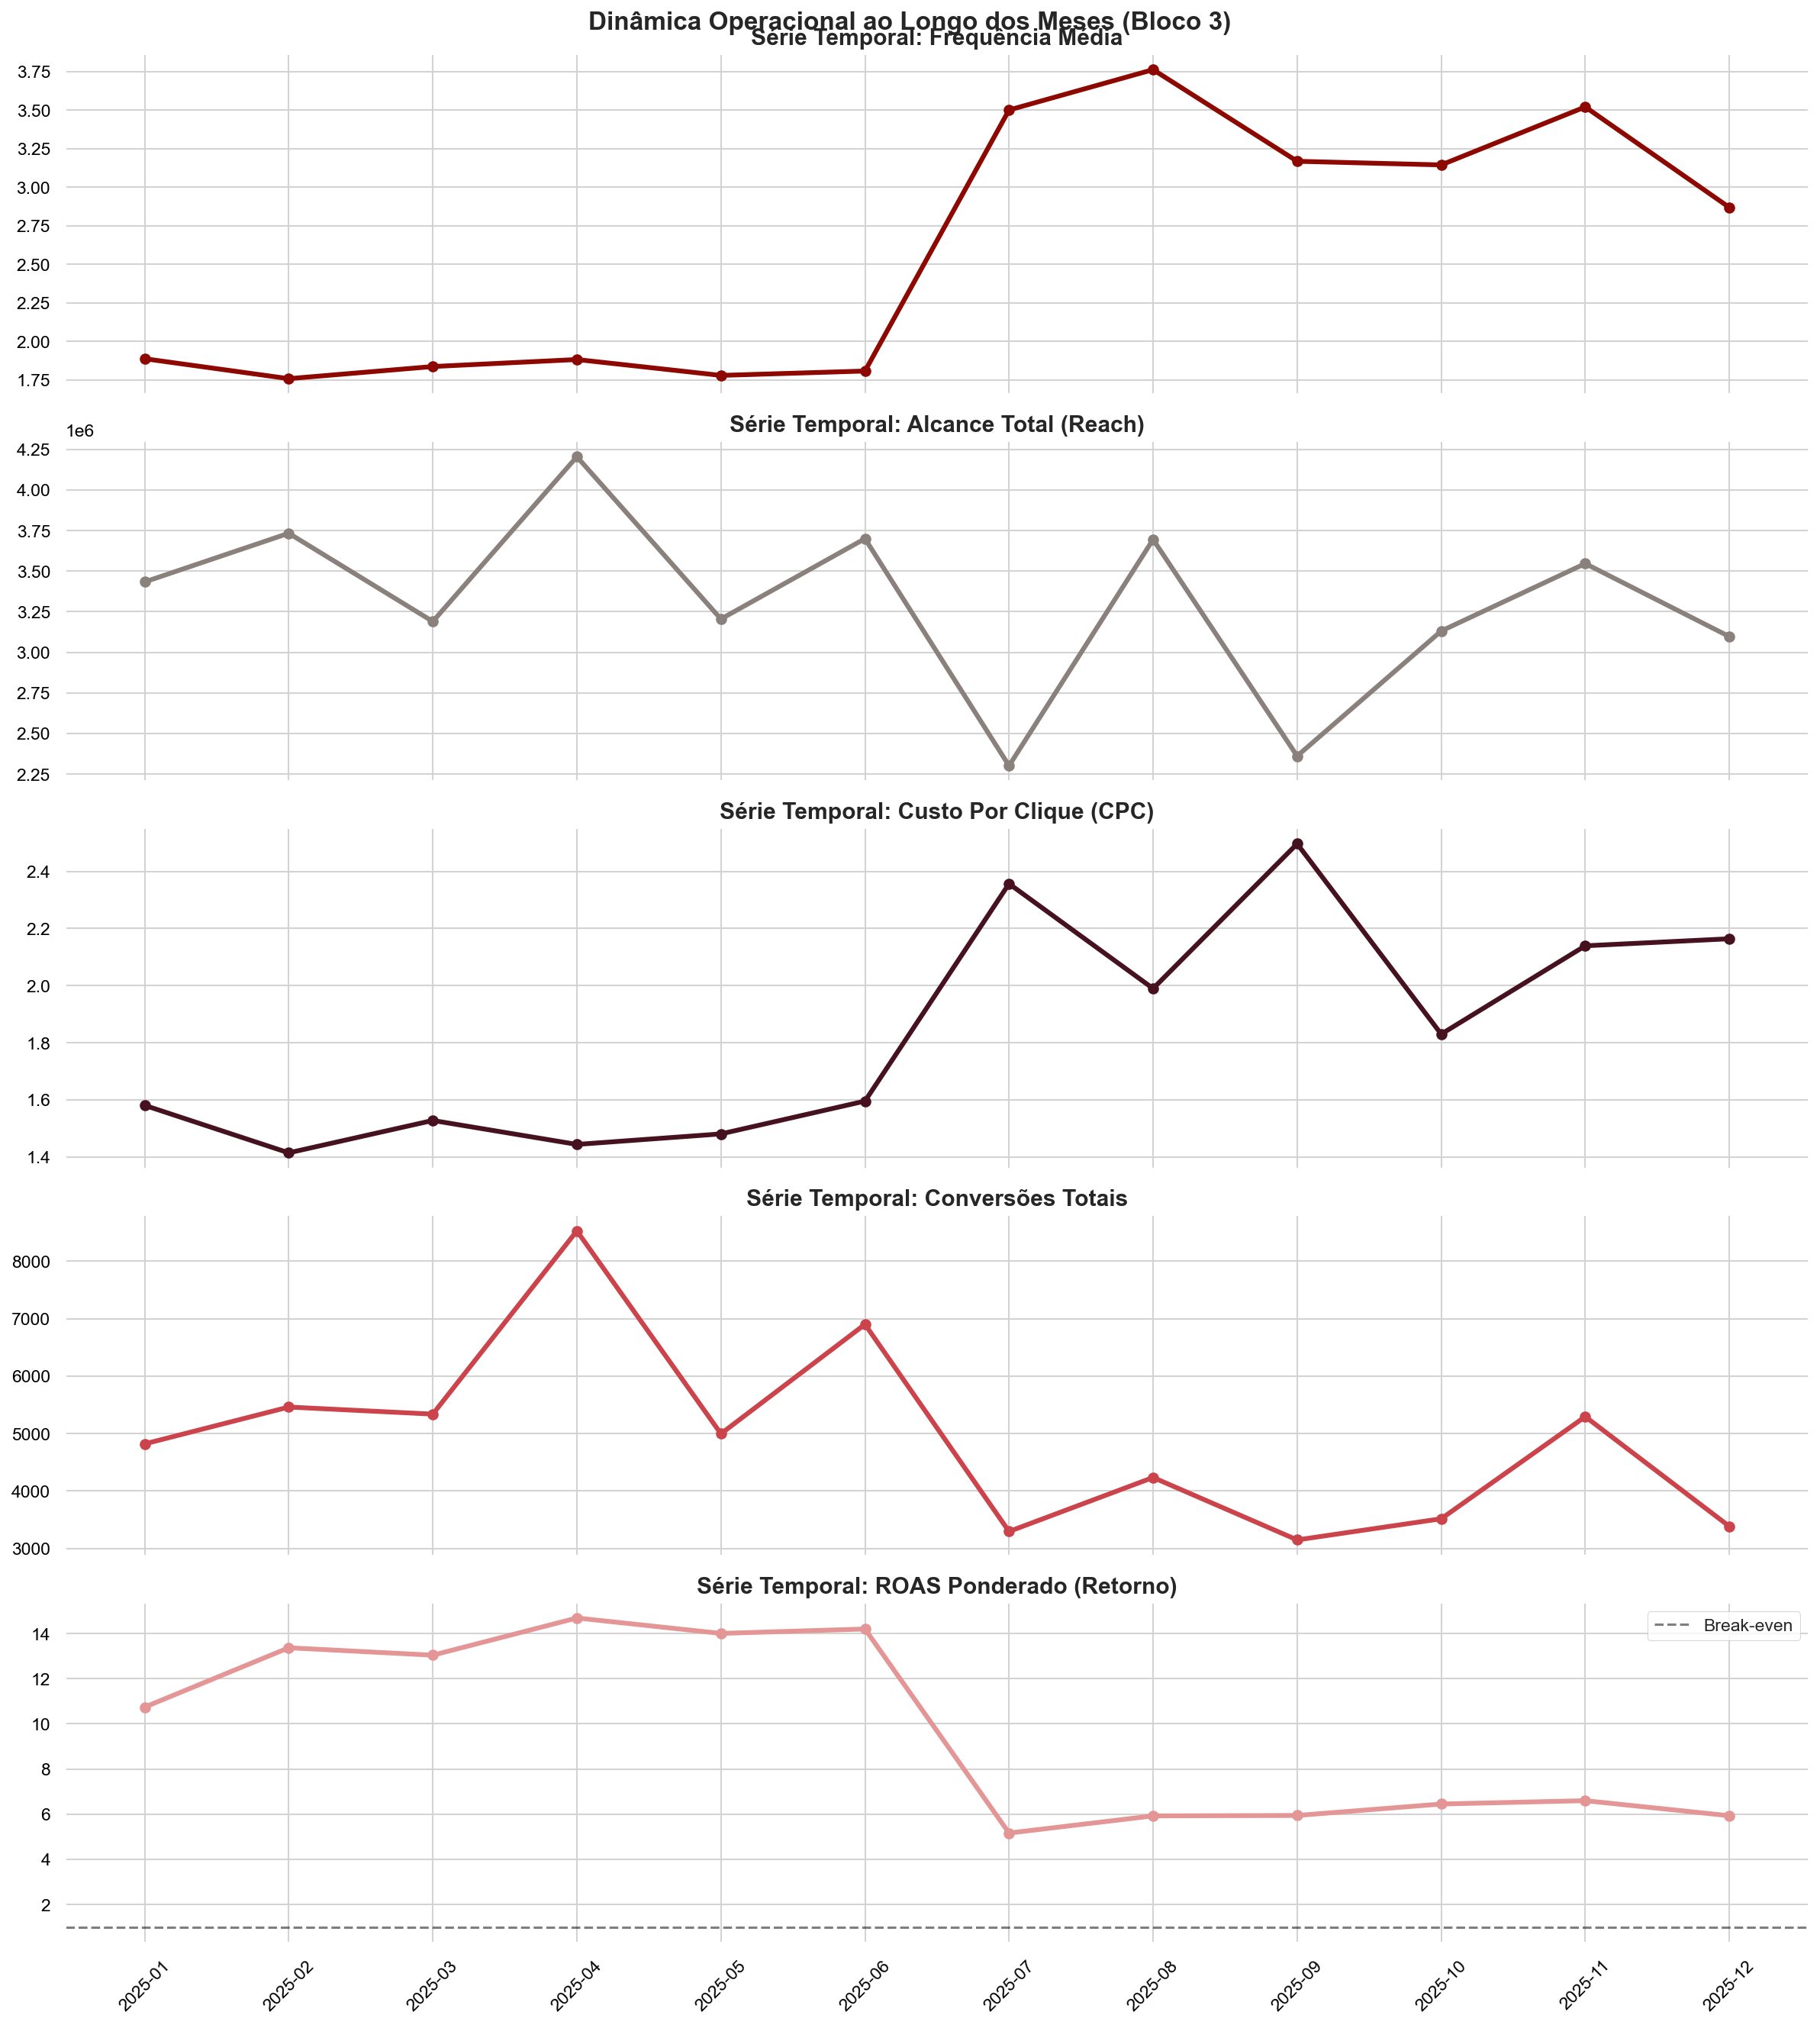

In [4]:
# Chamada Limpa para o Notebook
dossie_visual_marketing('../artifacts/dados_case_ecoshop.csv')

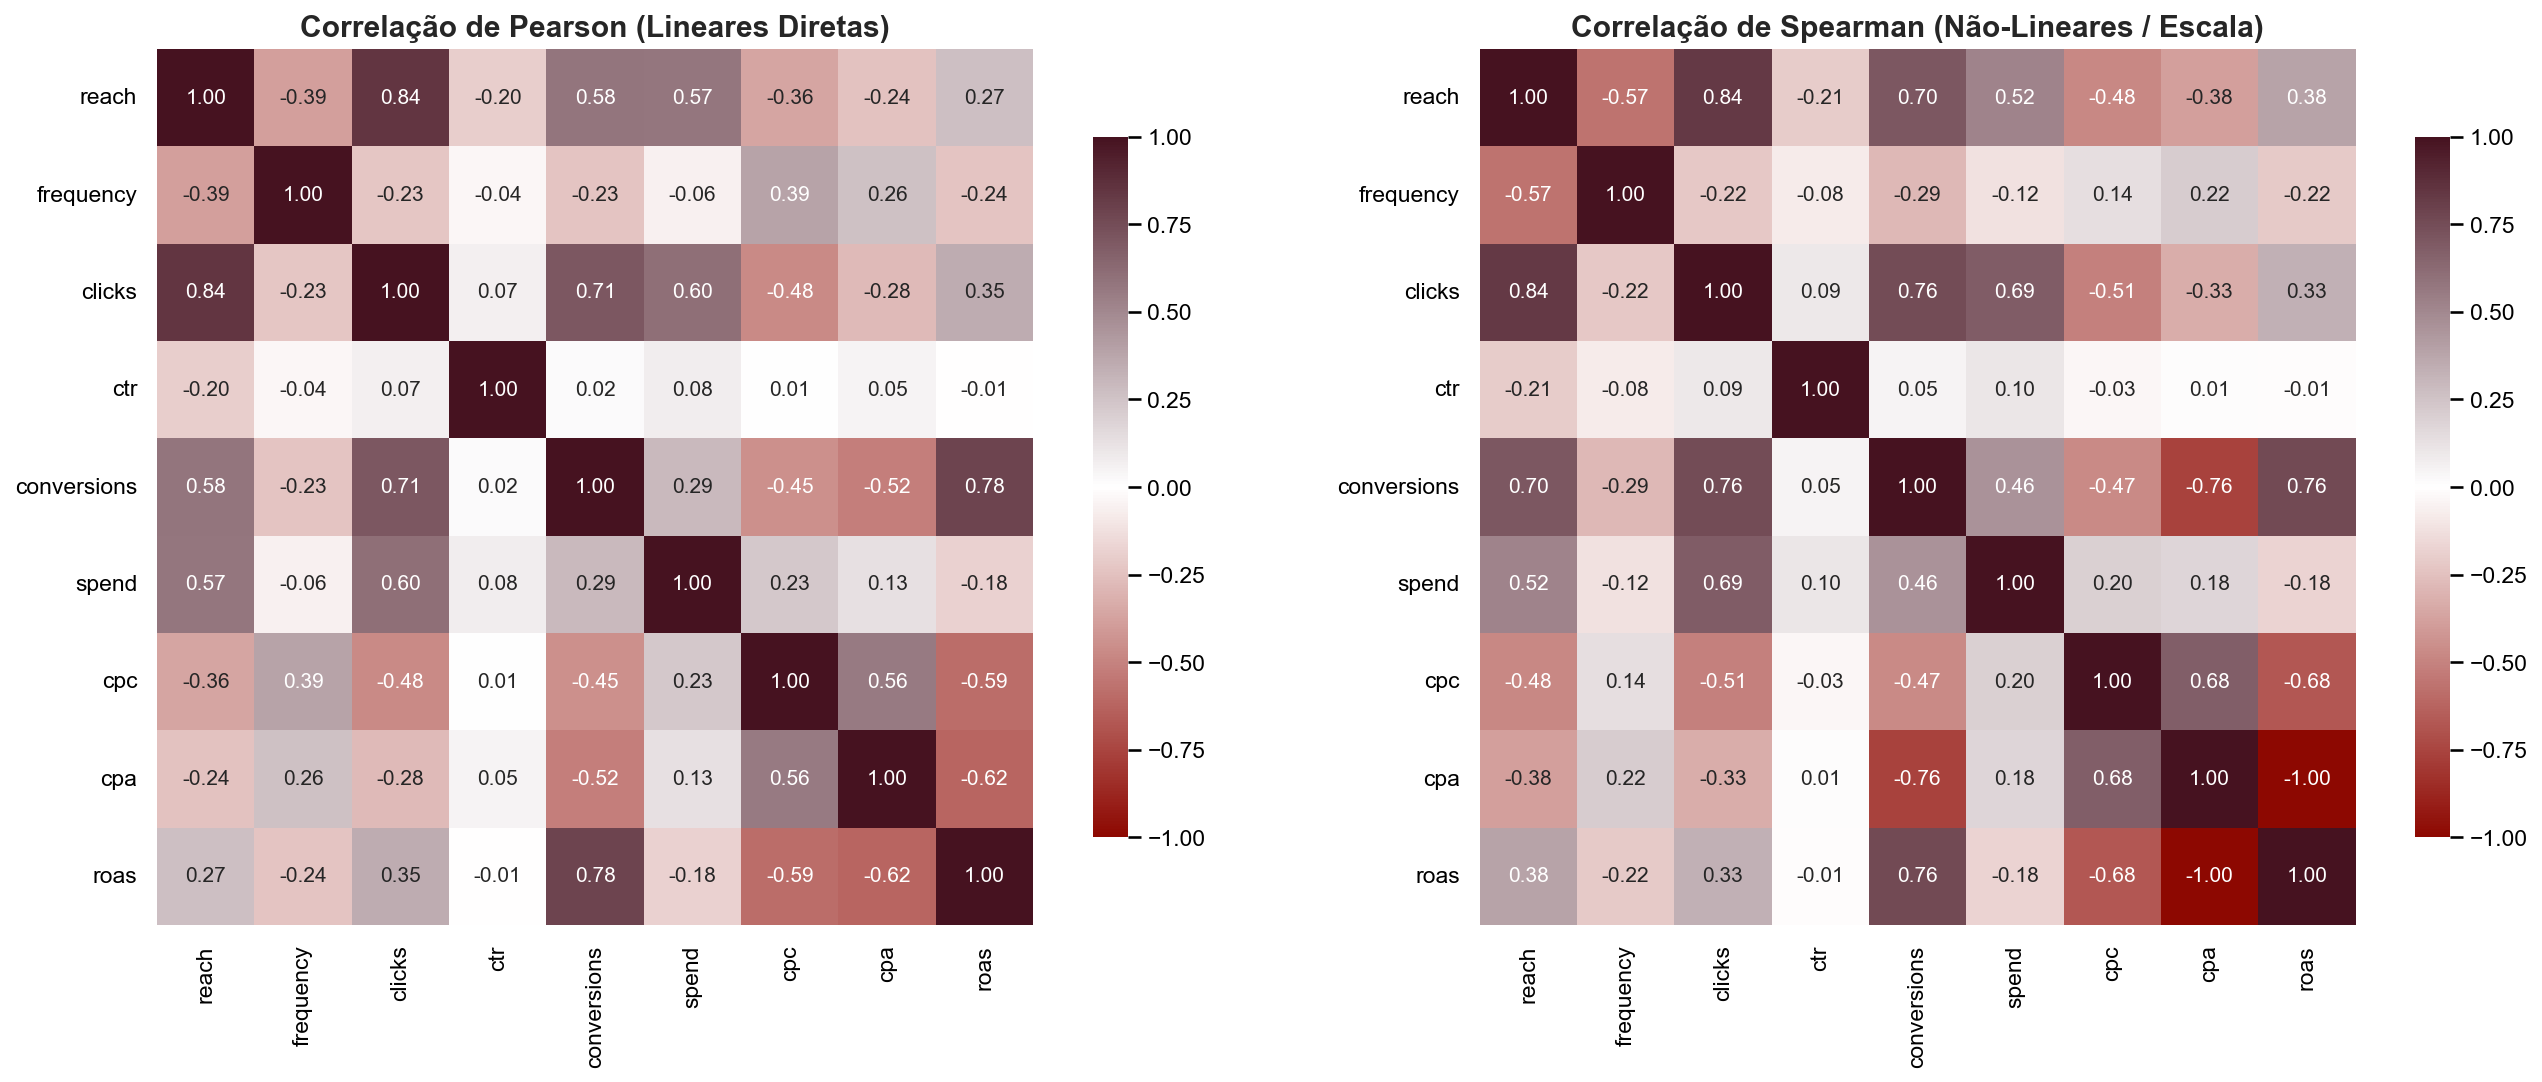

In [5]:
analise_correlacao_avancada('../artifacts/dados_case_ecoshop.csv')

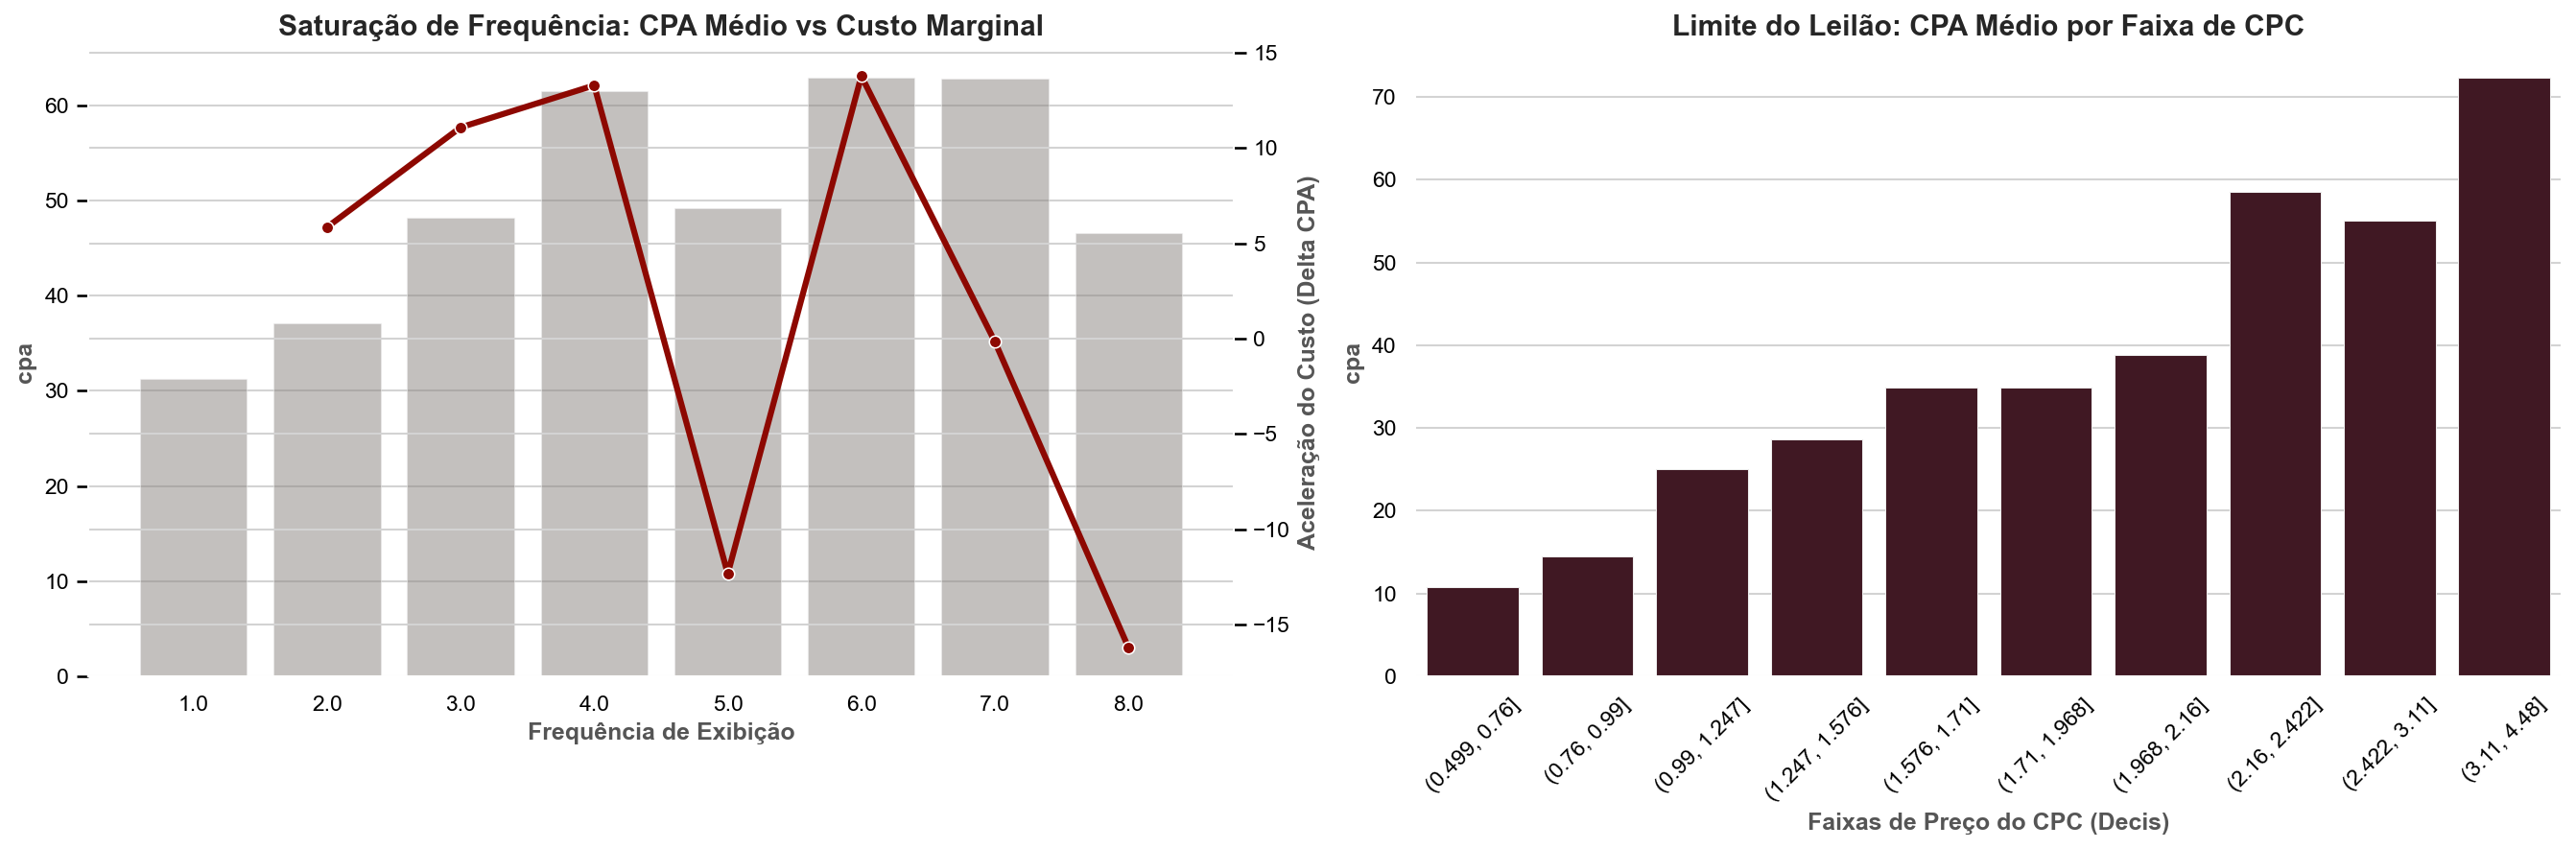

--- ANÁLISE DE CUSTO MARGINAL POR FREQUÊNCIA ---


,freq_bin,cpa,delta_cpa
1,2.0,37.109675,5.852423
2,3.0,48.200000,11.090325
3,4.0,61.495714,13.295714
4,5.0,49.161667,-12.334048
5,6.0,62.945000,13.783333
6,7.0,62.785000,-0.160000
7,8.0,46.571111,-16.213889


In [6]:
tabela_marginal = analise_limites_eficiencia('../artifacts/dados_case_ecoshop.csv')

print("--- ANÁLISE DE CUSTO MARGINAL POR FREQUÊNCIA ---")
display(tabela_marginal[['freq_bin', 'cpa', 'delta_cpa']].dropna())

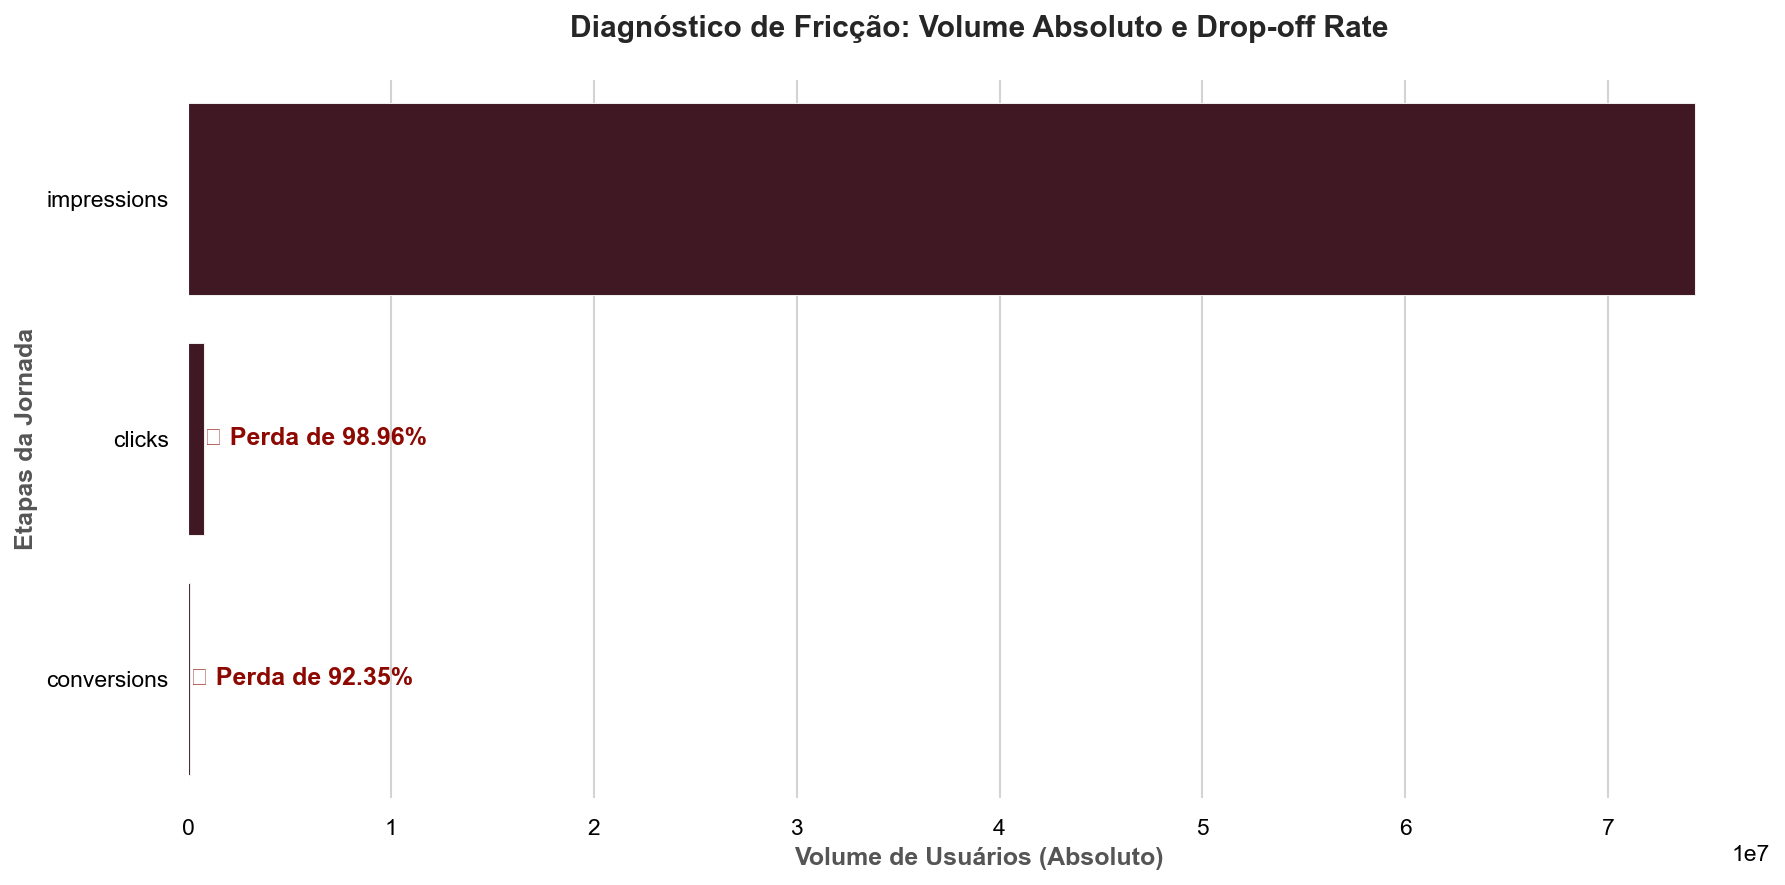

--- MATRIZ DE GARGALOS DO FUNIL ---


,etapa,volume,drop_off_str
0,impressions,74282479,0.0%
1,clicks,770765,98.96%
2,conversions,58929,92.35%


In [7]:
df_funil = analise_funil_conversao('../artifacts/dados_case_ecoshop.csv')
print("--- MATRIZ DE GARGALOS DO FUNIL ---")
display(df_funil[['etapa', 'volume', 'drop_off_str']])


--- RADIOGRAFIA DE ELASTICIDADE (MODELO LOG-LOG) ---
R-squared: 0.4940
Interpretando: Cada 1% de aumento na feature altera o CPA em X%
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1786      0.424      5.136      0.000       1.344       3.013
frequency      0.1746      0.070      2.486      0.013       0.036       0.313
clicks         0.0482      0.053      0.907      0.365      -0.056       0.153
ctr            0.0938      0.110      0.851      0.396      -0.123       0.311
cpc            1.1897      0.079     15.138      0.000       1.035       1.344


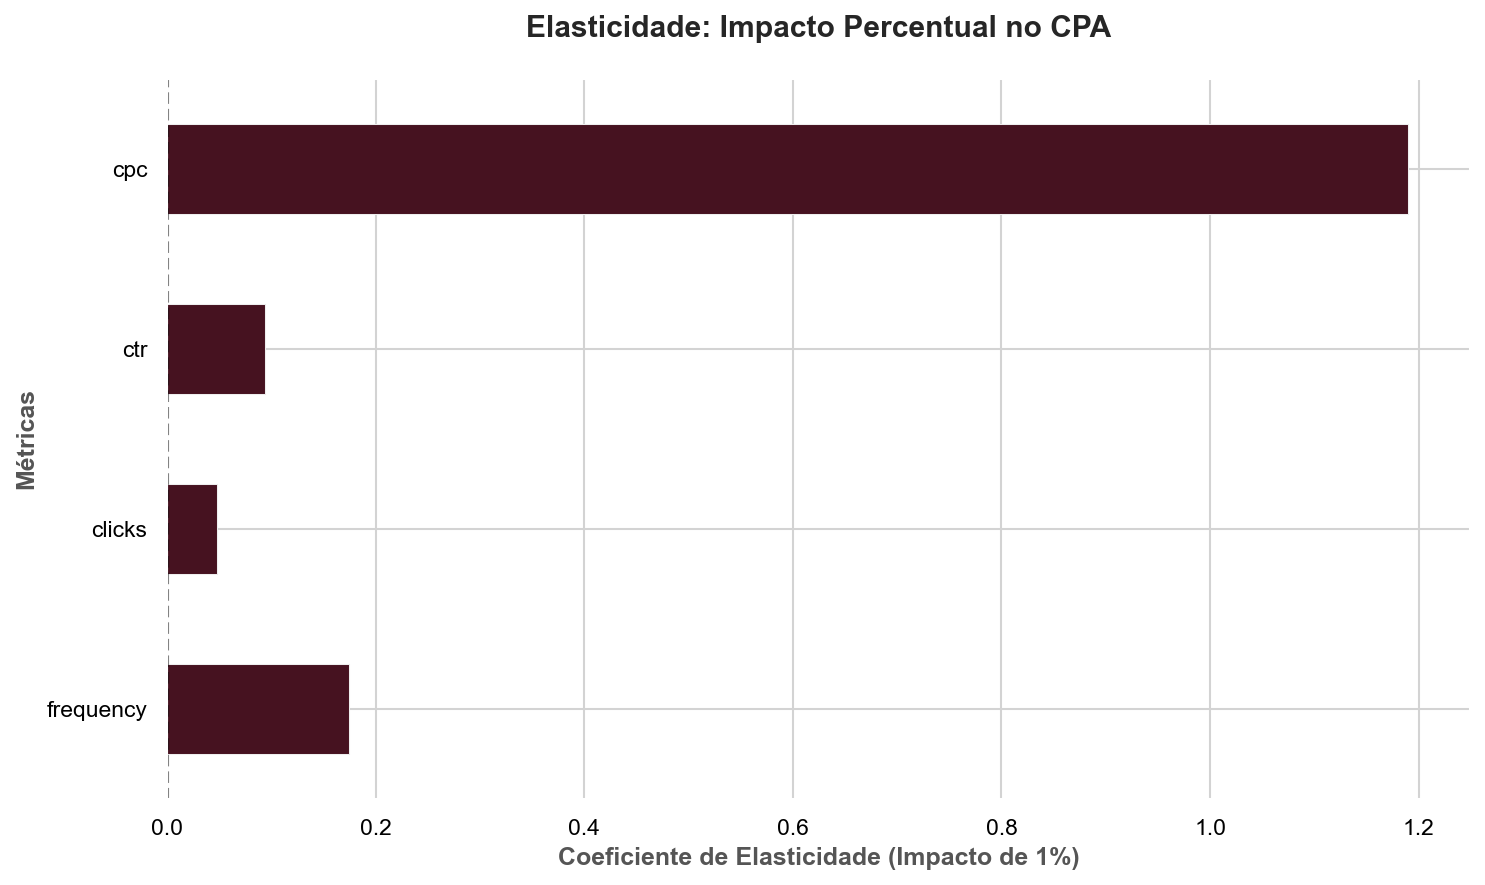

                            OLS Regression Results                            
Dep. Variable:                    cpa   R-squared:                       0.494
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     84.22
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           7.88e-50
Time:                        20:43:33   Log-Likelihood:                -332.67
No. Observations:                 350   AIC:                             675.3
Df Residuals:                     345   BIC:                             694.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1786      0.424      5.136      0.0

In [8]:
# 1. Roda o modelo e guarda o objeto do modelo na variável
modelo_final = analise_modelo_elasticidade('../artifacts/dados_case_ecoshop.csv')

# 2. Se quiser ver o sumário completo depois, você usa a variável criada:
print(modelo_final.summary())

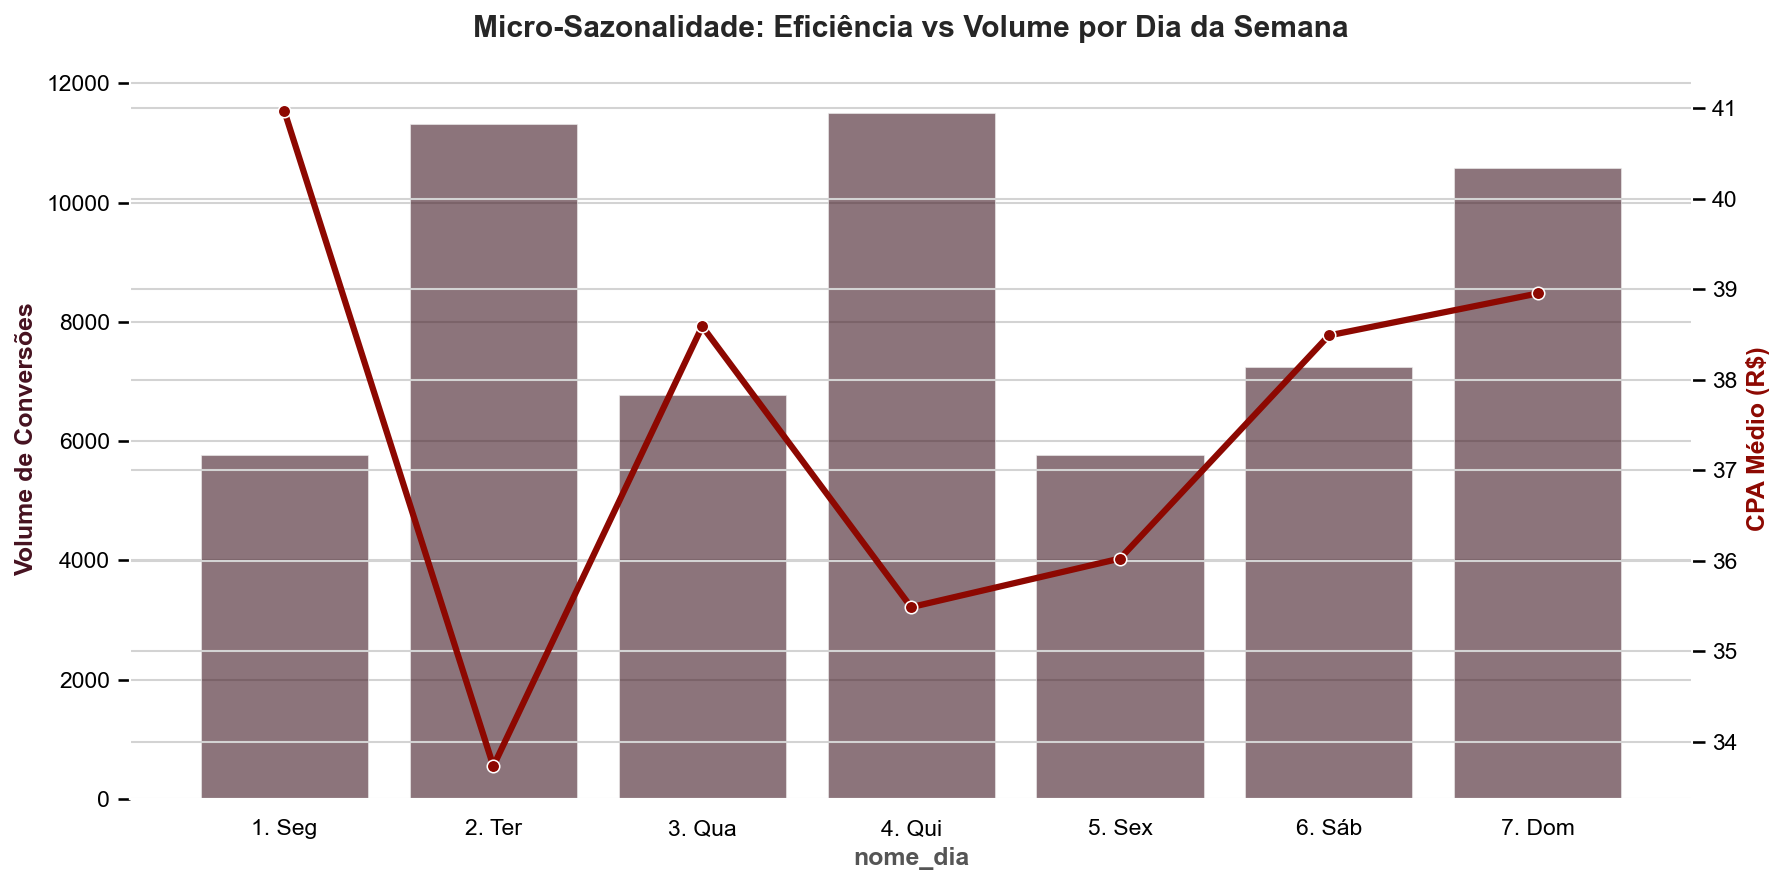

--- RANKING DE EFICIÊNCIA POR DIA ---


,nome_dia,cpa,conversions
1,2. Ter,33.73,11310
3,4. Qui,35.49,11502
4,5. Sex,36.03,5768
5,6. Sáb,38.49,7234
2,3. Qua,38.59,6770
6,7. Dom,38.96,10577
0,1. Seg,40.97,5768


In [9]:
# Executa a análise (se sua coluna de data tiver outro nome, mude o segundo parâmetro)
df_sazonalidade = analise_sazonalidade_semanal('../artifacts/dados_case_ecoshop.csv', coluna_data='date')

if df_sazonalidade is not None:
    print("--- RANKING DE EFICIÊNCIA POR DIA ---")
    display(df_sazonalidade.sort_values('cpa').round(2))

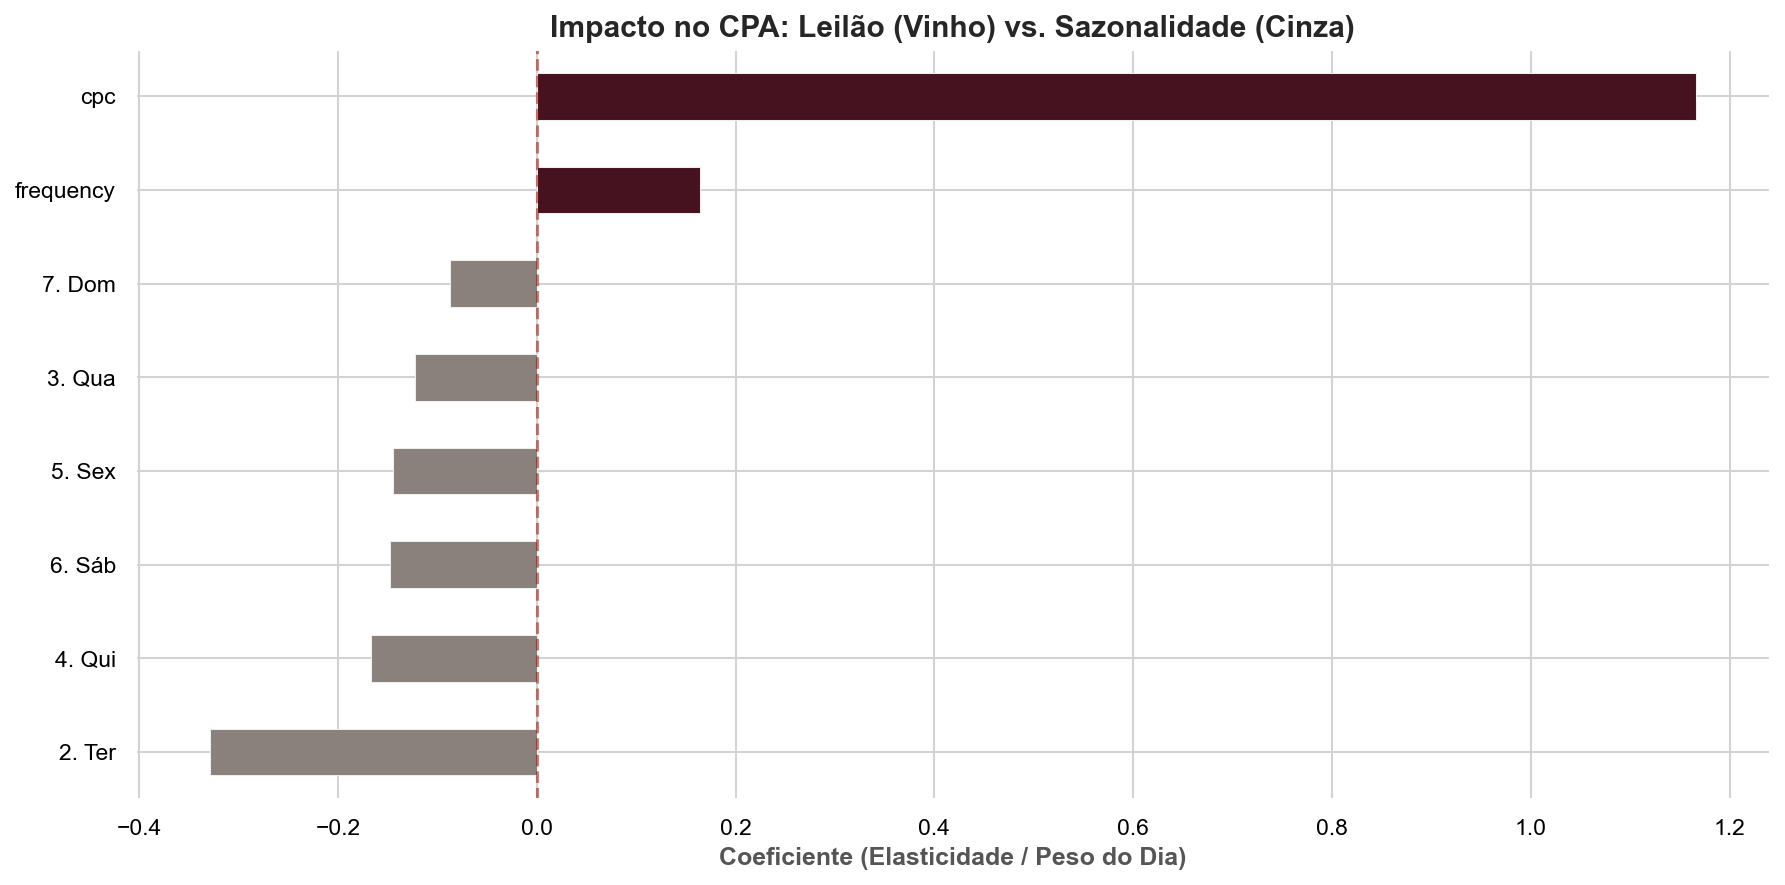

--- 4. A PROVA DEFINITIVA (LEILÃO + SAZONALIDADE) ---
R-squared Total: 0.5037

Resumo Estatístico:
                            OLS Regression Results                            
Dep. Variable:                    cpa   R-squared:                       0.504
Model:                            OLS   Adj. R-squared:                  0.492
Method:                 Least Squares   F-statistic:                     43.25
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           1.50e-47
Time:                        20:43:33   Log-Likelihood:                -329.31
No. Observations:                 350   AIC:                             676.6
Df Residuals:                     341   BIC:                             711.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

In [10]:
# Roda o modelo híbrido (Leilão + Calendário)
modelo_hibrido = analise_modelo_hibrido('../artifacts/dados_case_ecoshop.csv', coluna_data='date')

# Exibe a Prova Definitiva
print("--- 4. A PROVA DEFINITIVA (LEILÃO + SAZONALIDADE) ---")
if modelo_hibrido:
    print(f"R-squared Total: {modelo_hibrido.rsquared:.4f}")
    print("\nResumo Estatístico:")
    print(modelo_hibrido.summary())

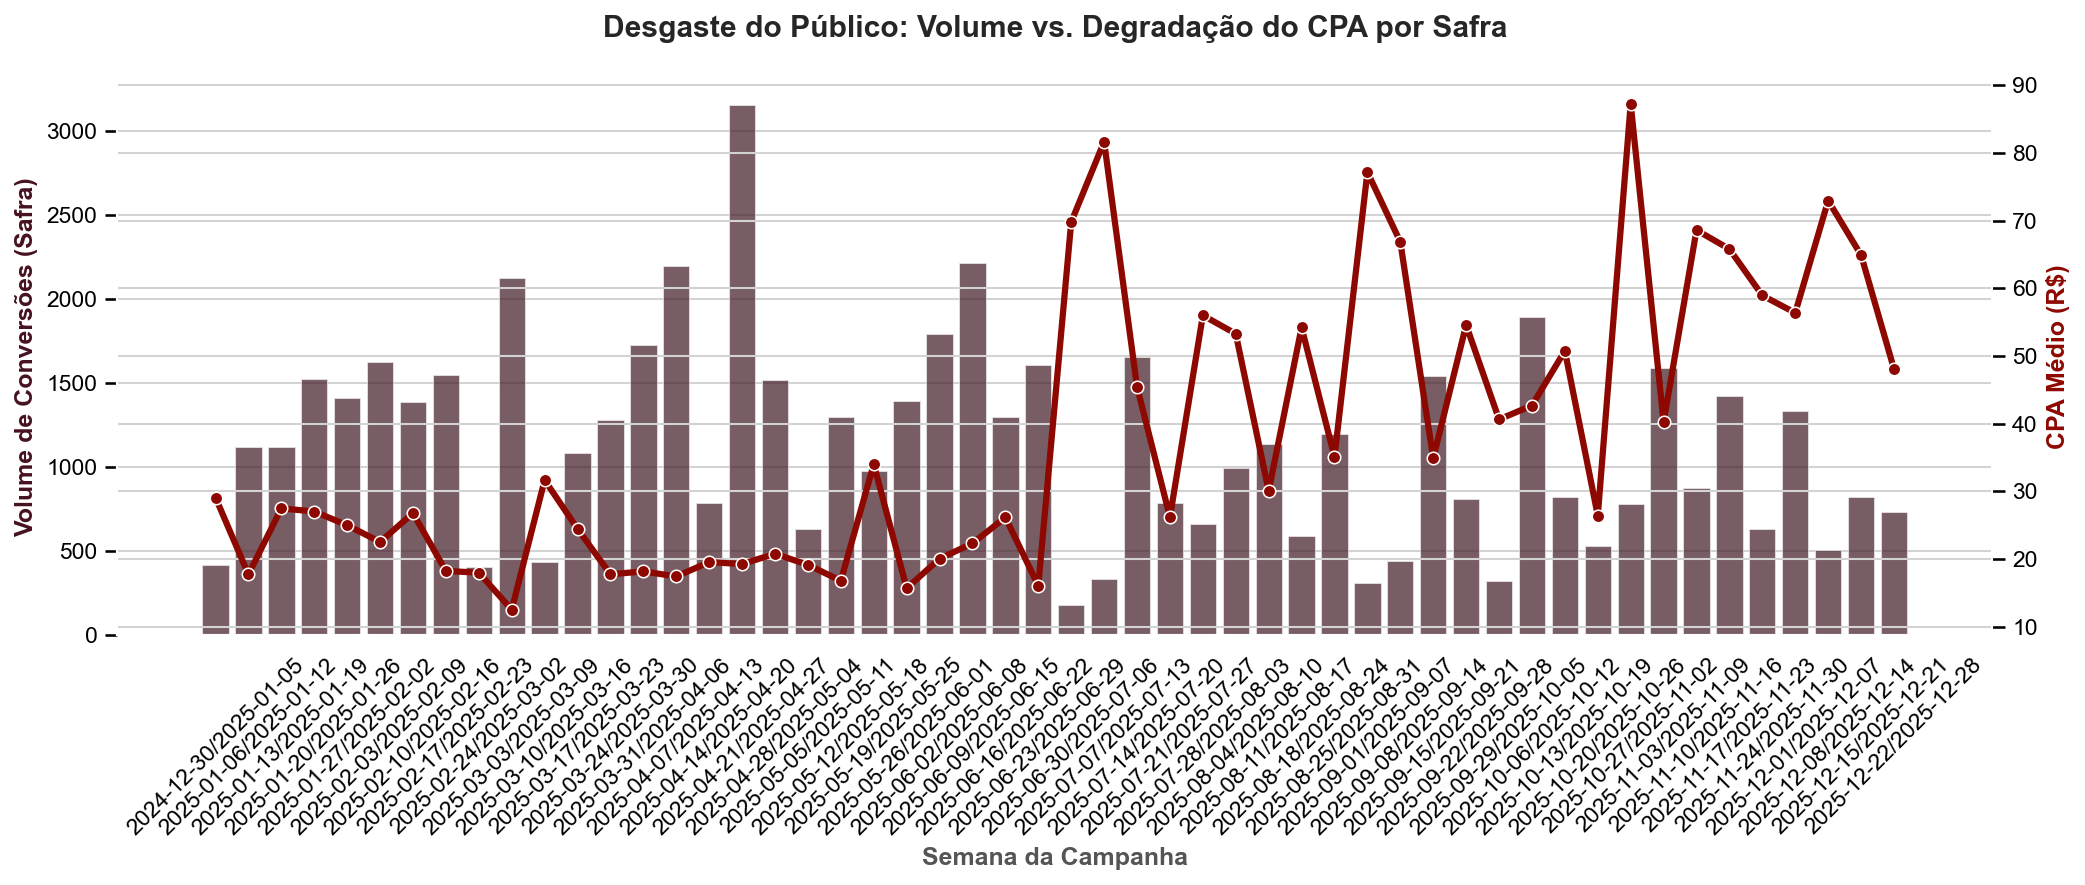

--- DEGRADAÇÃO DAS SAFRAS SEMANAIS ---


,safra_str,conversions,cpa
0,2024-12-30/2025-01-05,417,29.11
1,2025-01-06/2025-01-12,1118,17.76
2,2025-01-13/2025-01-19,1116,27.51
3,2025-01-20/2025-01-26,1525,27.04
4,2025-01-27/2025-02-02,1412,25.02
5,2025-02-03/2025-02-09,1626,22.55
6,2025-02-10/2025-02-16,1388,26.81
7,2025-02-17/2025-02-23,1549,18.25
8,2025-02-24/2025-03-02,402,18.02
9,2025-03-03/2025-03-09,2126,12.55


In [11]:
# Executa o diagnóstico de desgaste
df_vintage = analise_vintage_semanal('../artifacts/dados_case_ecoshop.csv', coluna_data='date')

# Exibe a tabela de degradação para análise de números brutos
if df_vintage is not None:
    print("--- DEGRADAÇÃO DAS SAFRAS SEMANAIS ---")
    display(df_vintage[['safra_str', 'conversions', 'cpa']].round(2))

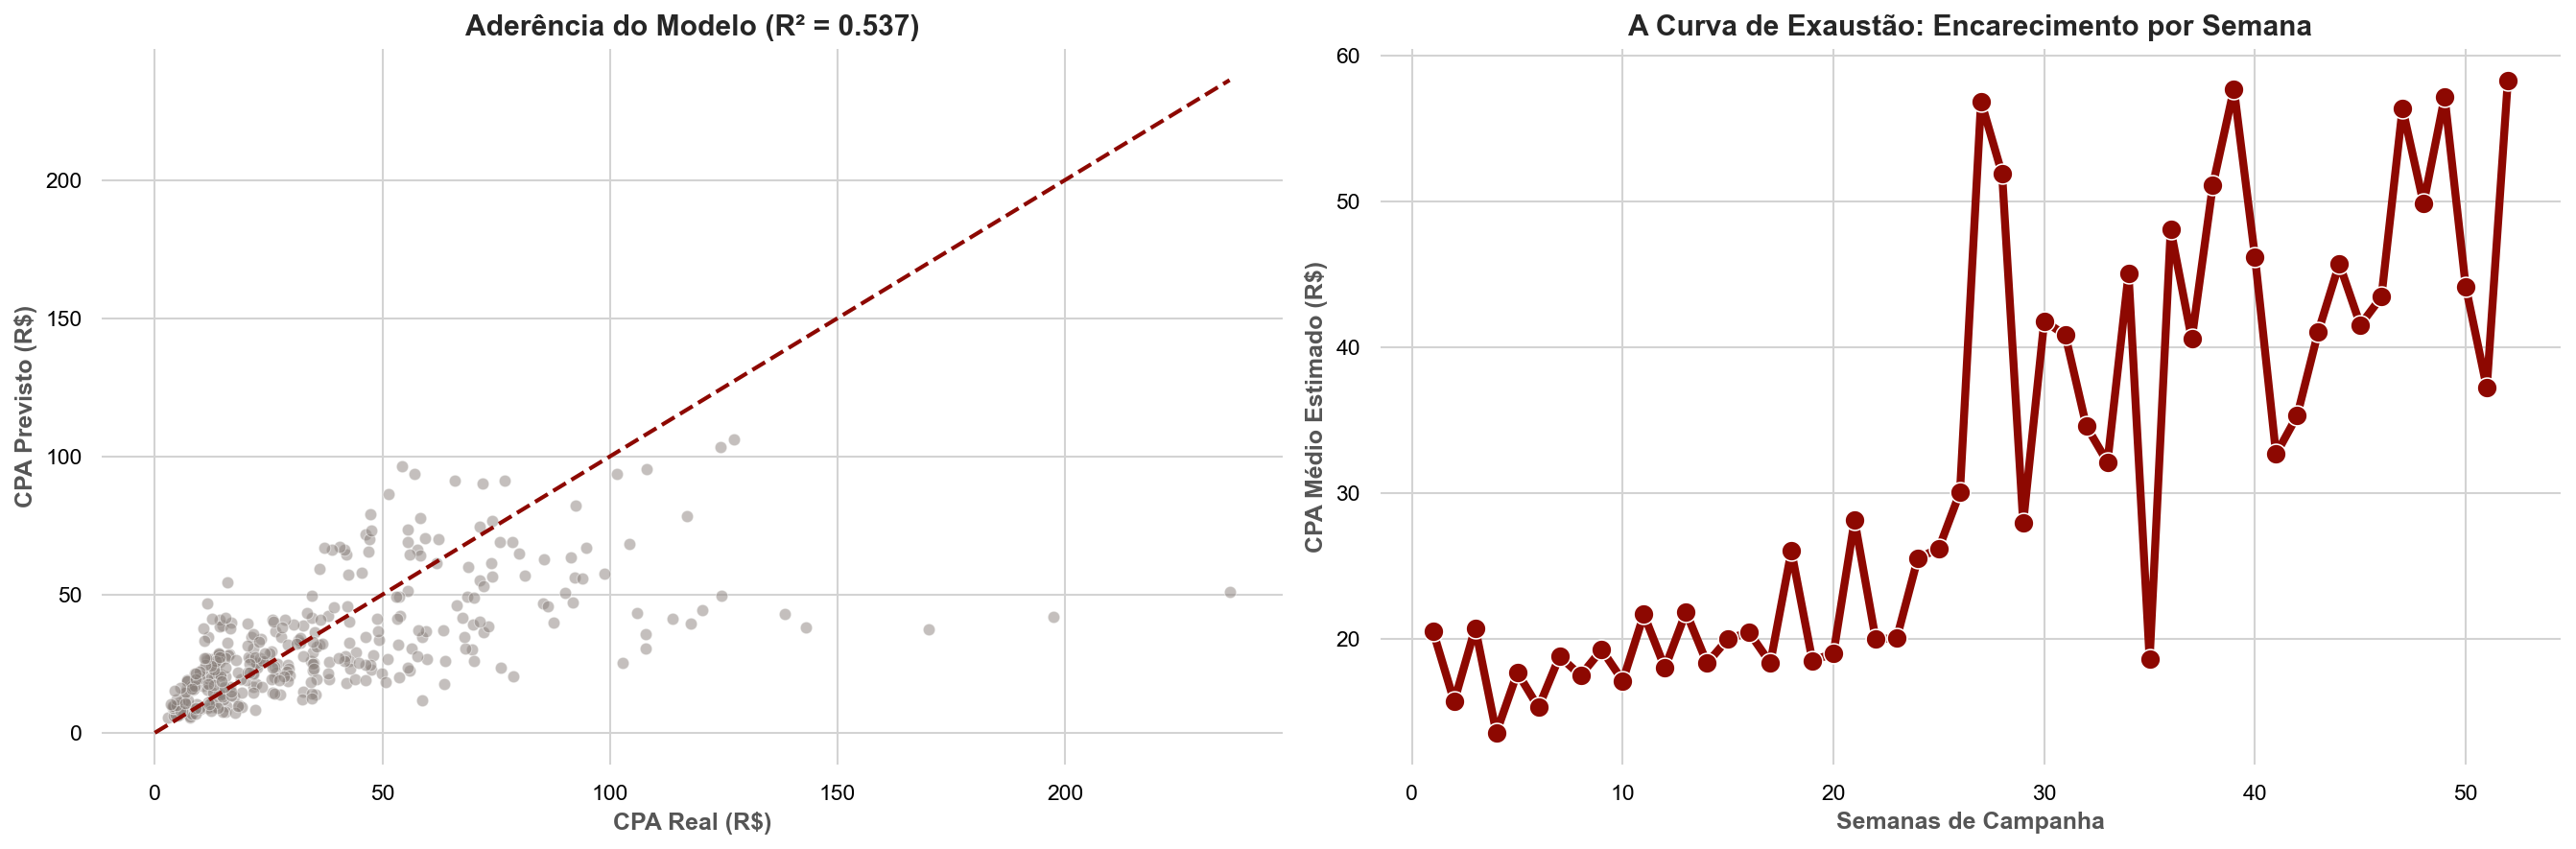

--- DIAGNÓSTICO ESTRATÉGICO ---
Impacto do Tempo: A cada semana, o CPA base sobe aproximadamente 1.39%


In [13]:
modelo_final, df_predicoes = analise_exaustao_preditiva('../artifacts/dados_case_ecoshop.csv', coluna_data='date')

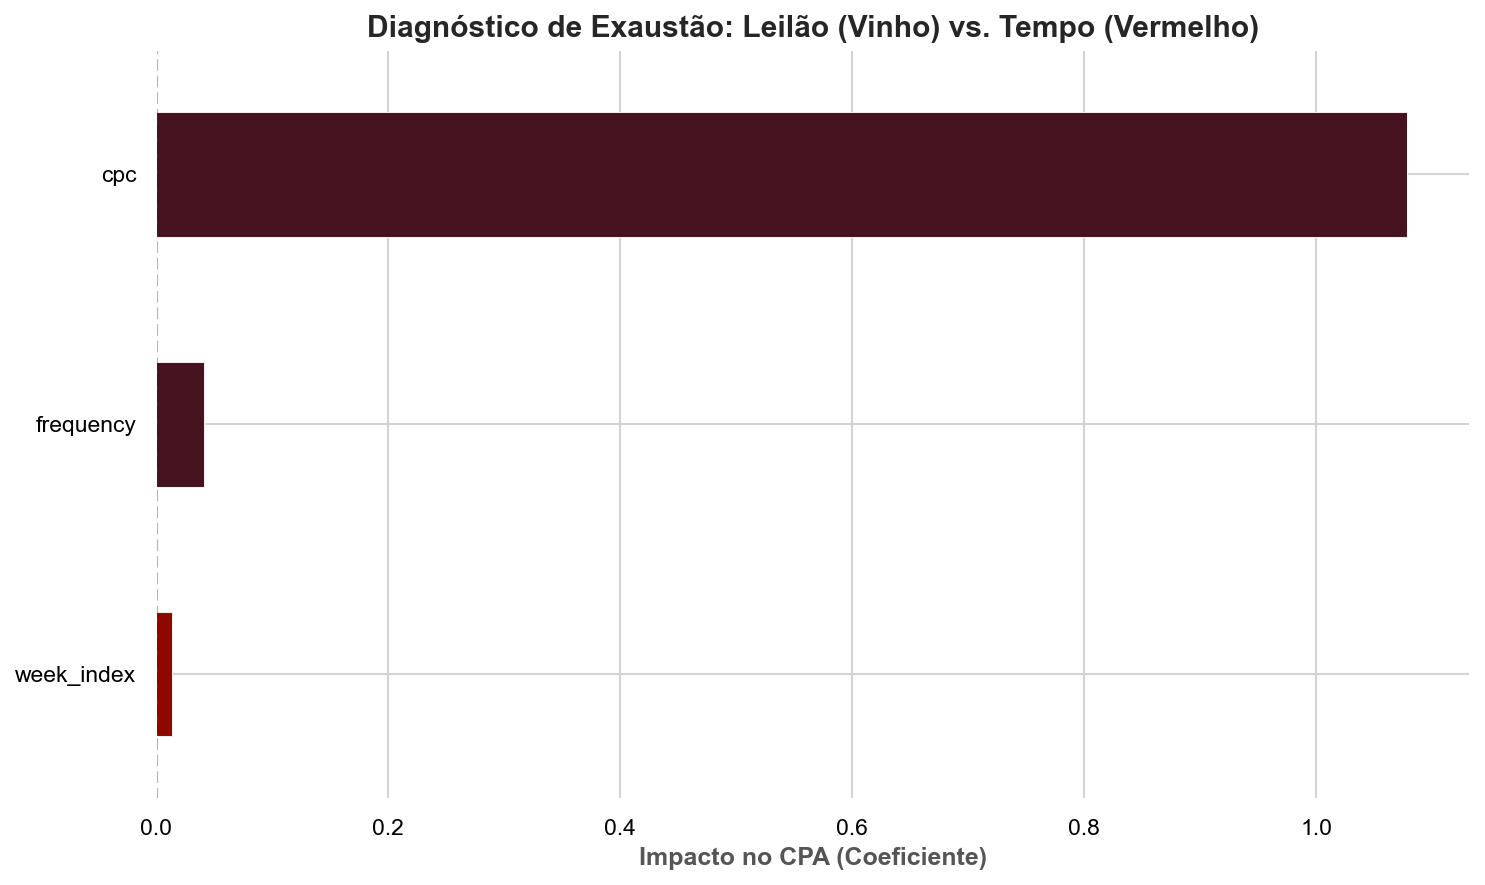

--- 5. MODELO DE EXAUSTÃO DE AUDIÊNCIA ---
Poder de Explicação (R-squared): 0.5367

Análise de Significância:
                            OLS Regression Results                            
Dep. Variable:                    cpa   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.533
Method:                 Least Squares   F-statistic:                     133.6
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           1.71e-57
Time:                        20:43:34   Log-Likelihood:                -317.26
No. Observations:                 350   AIC:                             642.5
Df Residuals:                     346   BIC:                             657.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------

In [12]:

modelo_exaustao = analise_modelo_exaustao('../artifacts/dados_case_ecoshop.csv', coluna_data='date')


print("--- 5. MODELO DE EXAUSTÃO DE AUDIÊNCIA ---")
if modelo_exaustao:
    print(f"Poder de Explicação (R-squared): {modelo_exaustao.rsquared:.4f}")
    print("\nAnálise de Significância:")
    print(modelo_exaustao.summary())